In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation 
plt.rcParams.update({'font.size': 16})
import glob
import matplotlib.cm as cm

In [2]:
import torch
import numpy as np
import networkx as nx
import os

from floorplans.lidar.lidar import Lidar2D, OnlineTrajectoryLidarDataset

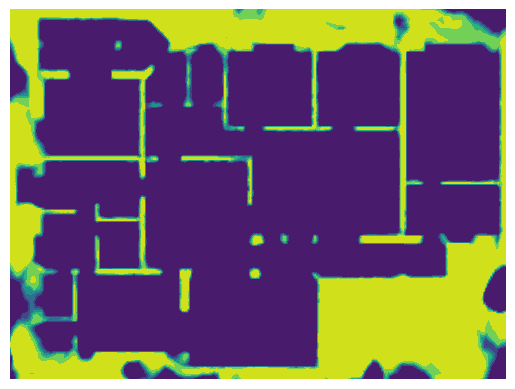

In [13]:
results_dir_minimal = "../results/2024-07-30_19-18_dist_online_dense_minimal"
min_results2 = torch.load(os.path.join(results_dir_minimal, "sonata_results.pt"), map_location=torch.device("cpu"))
min_sonata_den=min_results2["mesh_grid_density"]
sonata_pred2 = (torch.squeeze(min_sonata_den[-1]))[0 ,:]
plt.tricontourf(locs[:, 0], locs[:, 1], sonata_pred2)
#remove axis
plt.axis('off')
plt.savefig("distributed_result.png", dpi=300, bbox_inches='tight')

In [16]:
solo_dir="../results_paper/2024-09-19_21-07_dist_online_dense_solo"
# solo_dir="../results_iros/2025-06-06_15-30_dist_online_dense_repeat2_eval_mesh"
solo_results=torch.load(os.path.join(solo_dir, "solo_results.pt"), map_location="cpu")
squeeze_list=[]
locs = solo_results[0]["mesh_grid"]
for i in range(len(solo_results)):
    
    dens = solo_results[i]["mesh_list"]
    squeeze_list.append(torch.squeeze(dens[-1]))
    plt.tricontourf(locs[:, 0], locs[:, 1], (torch.squeeze(dens[-1])))
    plt.axis('off')
    plt.savefig(f"solo_result_{i}.png", dpi=300, bbox_inches='tight')
    plt.clf()
# 


# mean_squeeze_dens = torch.stack(squeeze_list, dim=0).mean(dim=0)

# plt.tricontourf(locs[:, 0], locs[:, 1], (torch.squeeze(dens[-1])))
# plt.tricontourf(locs[:, 0], locs[:, 1], mean_squeeze_dens)
#remove axis
# plt.savefig("mean_solo_result.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

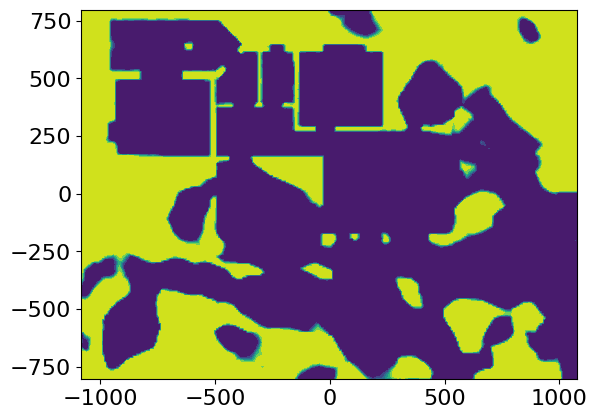

In [ ]:
# solo_dir="../results_paper/2024-09-19_18-29_dist_online_dense_solo"
solo_dir="../results_paper/2024-09-19_18-29_dist_online_dense_solo"

solo_results=torch.load(os.path.join(solo_dir, "solo_results.pt"), map_location="cpu")
dens = solo_results[0]["mesh_list"]

locs = solo_results[0]["mesh_grid"]



plt.tricontourf(locs[:, 0], locs[:, 1], (torch.squeeze(dens[-1])))

In [12]:
v_mean

tensor([17.3564,  4.7985,  4.5800,  4.3268,  4.9456,  4.3359,  4.2271,  5.1770,
         4.9284,  4.0111,  5.2114,  4.6720,  3.6508,  4.3134,  4.5428,  3.3371,
         3.9159,  5.9858,  3.4812,  6.1625,  4.5113,  3.2842,  4.0974,  3.6839,
         2.9183,  3.4813,  4.4241,  3.7082,  5.1007,  3.6221,  3.1572,  3.2107,
         4.1613,  3.3187,  3.2268,  4.2908,  2.7059,  2.8038,  3.3888,  3.3897,
         3.5070,  2.8155,  2.6717,  4.4921,  3.4736,  2.7130,  4.9520,  3.0348,
         3.0656,  3.6508,  3.2800,  3.4026,  2.7420,  4.4957,  3.5413,  3.2431,
         2.9865,  3.6715,  2.6476,  4.7140,  3.7085,  2.5734,  4.4539,  3.1713,
         2.2595,  3.1966,  3.7545,  2.4299,  4.8812,  2.9550,  2.7116,  3.0976,
         3.2371,  2.3677,  2.9384,  2.7702,  2.6843,  3.0288,  3.2954,  2.2007,
         2.3700,  2.0547,  3.2840,  3.2344,  2.4849,  2.3610,  2.6911,  3.4391,
         2.0361,  2.4110,  4.0834,  2.2630,  2.9329,  3.2258,  2.5138,  3.8020,
         2.3645,  4.0076,  2.2372,  3.31

In [19]:
comp_iter5

array([    0.,   120.,   240.,   360.,   480.,   600.,   720.,   840.,
         960.,  1080.,  1200.,  1320.,  1440.,  1560.,  1680.,  1800.,
        1920.,  2040.,  2160.,  2280.,  2400.,  2520.,  2640.,  2760.,
        2880.,  3000.,  3120.,  3240.,  3360.,  3480.,  3600.,  3720.,
        3840.,  3960.,  4080.,  4200.,  4320.,  4440.,  4560.,  4680.,
        4800.,  4920.,  5040.,  5160.,  5280.,  5400.,  5520.,  5640.,
        5760.,  5880.,  6000.,  6120.,  6240.,  6360.,  6480.,  6600.,
        6720.,  6840.,  6960.,  7080.,  7200.,  7320.,  7440.,  7560.,
        7680.,  7800.,  7920.,  8040.,  8160.,  8280.,  8400.,  8520.,
        8640.,  8760.,  8880.,  9000.,  9120.,  9240.,  9360.,  9480.,
        9600.,  9720.,  9840.,  9960., 10080., 10200., 10320., 10440.,
       10560., 10680., 10800., 10920., 11040., 11160., 11280., 11400.,
       11520., 11640., 11760., 11880., 12000., 12120., 12240., 12360.,
       12480., 12600., 12720., 12840., 12960., 13080., 13200., 13320.,
      

(0.0, 8000.0)

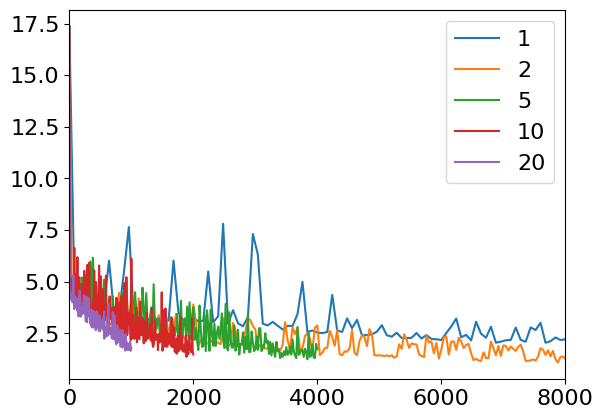

In [50]:
plt.plot(np.arange(v_iter1.shape[0])*80, torch.mean(v_iter1, dim=1), label='1')
plt.plot(np.arange(v_iter2.shape[0])*40, torch.mean(v_iter2, dim=1),    label='2')
plt.plot(np.arange(v_iter5.shape[0])*20, torch.mean(v_iter5, dim=1),    label='5')
plt.plot(np.arange(v_iter10.shape[0])*10, torch.mean(v_iter10, dim=1), label='10')
plt.plot(np.arange(v_iter20.shape[0])*5, torch.mean(v_iter20, dim=1),   label='20')
plt.legend()
plt.xlim([0,8000]) 

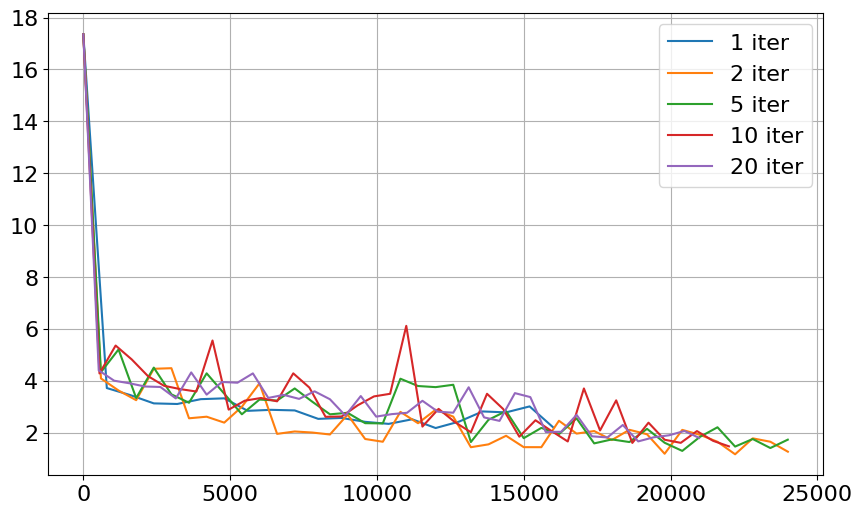

In [42]:
# quant_dir="../results/2024-05-14_08-30_dist_online_dense_PAPER"
iter_5_dir="../results_paper/2024-08-08_15-39_dist_online_dense_sonata_0.001"
iter_dir="../results_paper/2024-09-05_21-15_dist_online_dense_sonata_iter"
iter5=torch.load(os.path.join(iter_5_dir, "sonata_results.pt"),map_location=torch.device('cpu'))
v_iter5=torch.stack(iter5["validation_loss"])
comp_iter5=(np.array(iter5["forward_pass_count"])-12500)/12500
iter1=torch.load(os.path.join(iter_dir, "sonata_iter1_results.pt"),map_location=torch.device('cpu'))
v_iter1=torch.stack(iter1["validation_loss"])
comp_iter1=(np.array(iter1["forward_pass_count"])-12500)/12500
iter2=torch.load(os.path.join(iter_dir, "sonata_iter2_results.pt"),map_location=torch.device('cpu'))
v_iter2=torch.stack(iter2["validation_loss"])
comp_iter2=(np.array(iter2["forward_pass_count"])-12500)/12500

iter10=torch.load(os.path.join(iter_dir, "sonata_iter10_results.pt"),map_location=torch.device('cpu'))
v_iter10=torch.stack(iter10["validation_loss"])
comp_iter10=(np.array(iter10["forward_pass_count"])-12500)/12500

iter20=torch.load(os.path.join(iter_dir, "sonata_iter20_results.pt"),map_location=torch.device('cpu'))
v_iter20=torch.stack(iter20["validation_loss"])
comp_iter20=(np.array(iter20["forward_pass_count"])-12500)/12500

plt.figure(figsize=(10, 6))  # 设置图形的大小
ax = plt.subplot() 
step=5
ax.plot(comp_iter1[::step], torch.mean(v_iter1, dim=1)[::step], label="1 iter")
ax.plot(comp_iter2[::step], torch.mean(v_iter2, dim=1)[::step], label="2 iter")
ax.plot(comp_iter5[::step], torch.mean(v_iter5, dim=1)[::step], label="5 iter")
ax.plot(comp_iter10[::step], torch.mean(v_iter10, dim=1)[::step], label="10 iter")
ax.plot(comp_iter20[::step], torch.mean(v_iter20, dim=1)[::step], label="20 iter")
ax.grid()
ax.legend()

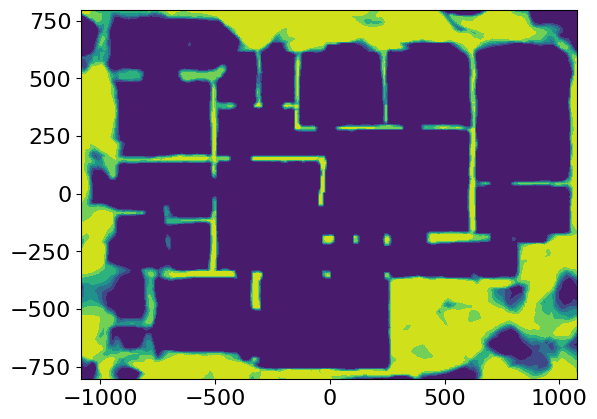

In [5]:
den=quant_result["mesh_grid_density"]
pred=(torch.squeeze(den[-1]))[0,:]

loc=quant_result["mesh_inputs"]
plt.tricontourf(loc[:,0], loc[:,1], pred)


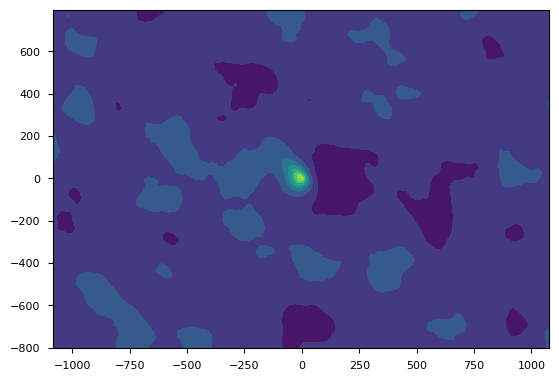

In [113]:
result_dinno_dir="../results/2024-06-24_19-56_dist_online_dense_ATC"
result_dinno=torch.load(os.path.join(result_dinno_dir, "dinno_log_results.pt"),map_location=torch.device('cpu'))
den=result_dinno["mesh_grid_density"]
pred=(torch.squeeze(den[-1]))[0,:]
loc=result_dinno["mesh_inputs"]
plt.tricontourf(loc[:,0], loc[:,1], pred)


In [5]:

results_dir0 = "../results/2024-05-13_07-02_dist_online_dense_PAPER"
results_dir= "../results/2024-04-08_08-53_dist_online_dense_PAPER"
results_sonata= "../results/2024-05-14_08-30_dist_online_dense_PAPER"
# results_sonata="../results/2024-05-13_07-02_dist_online_dense_PAPER"

result_kgt="../results/2024-06-19_18-58_dist_online_dense_ATC"


results1 = torch.load(os.path.join(results_dir, "dinno_log_results.pt"), map_location=torch.device("cpu"))
results2 = torch.load(os.path.join(results_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
results3 = torch.load(os.path.join(result_kgt, "kgt_results.pt"), map_location=torch.device("cpu"))
results4= torch.load(os.path.join(results_sonata, "sonata_results.pt"), map_location=torch.device("cpu"))


results_solo = torch.load(os.path.join(results_dir, "solo_results.pt"), map_location=torch.device("cpu"))


# Validation loss

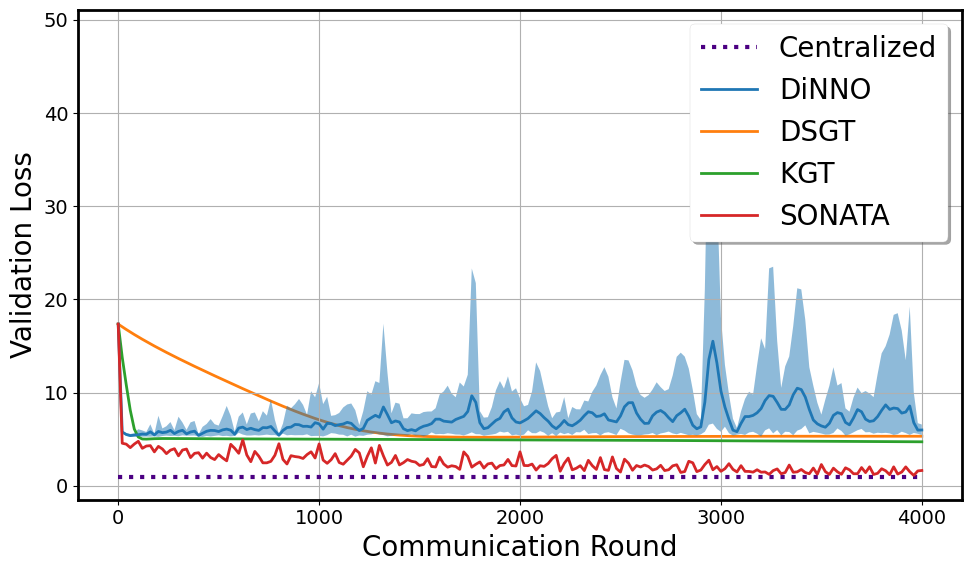

In [6]:
vl1 = torch.stack(results1["validation_loss"])
vl2 = torch.stack(results2["validation_loss"])
vl3 = torch.stack(results3["validation_loss"])
vl4 = torch.stack(results4["validation_loss"])

(fig, ax) = plt.subplots(figsize=(10, 6), tight_layout=True)

t = np.arange(vl1.shape[0]) * 20
plt.style.use('seaborn-v0_8-paper')  # 更改图表风格

#ind_color = "cornflowerblue"
#for i in results_solo.keys():
#    if i != 0:
#        ax.plot(t, results_solo[i]["validation_loss"] * np.ones_like(t),
#            color=ind_color, linestyle=":", linewidth=3)
#ax.plot(t, results_solo[0]["validation_loss"] * np.ones_like(t), 
#    color=ind_color, linestyle=":", label="Individual", linewidth=3)

centralized_vloss = 0.89
ax.plot(t, centralized_vloss * np.ones_like(t), color="indigo",
    linestyle=":", linewidth=3, label="Centralized")

cadmm_mean = torch.mean(vl1, dim=1)
cadmm_min = torch.amin(vl1, dim=1)
cadmm_max = torch.amax(vl1, dim=1)
dsgt_mean = torch.mean(vl2, dim=1)
dsgt_min = torch.amin(vl2, dim=1)
dsgt_max = torch.amax(vl2, dim=1)
kgt_mean = torch.mean(vl3, dim=1)
kgt_min = torch.amin(vl3, dim=1)
kgt_max = torch.amax(vl3, dim=1)
sonata_mean= torch.mean(vl4,dim=1)
sonata_min = torch.amin(vl4, dim=1)
sonata_max = torch.amax(vl4, dim=1)


ax.plot(t, cadmm_mean, linewidth=2, label="DiNNO",zorder=3)
ax.plot(t, dsgt_mean, linewidth=2, label="DSGT",zorder=1)
ax.plot(t, kgt_mean, linewidth=2, label="KGT",zorder=2)
ax.plot(t, sonata_mean, linewidth=2, label="SONATA",zorder=4)
ax.fill_between(t, cadmm_min, cadmm_max, alpha=0.5)
ax.fill_between(t, dsgt_min, dsgt_max,  alpha=0.5)
ax.fill_between(t, kgt_min, kgt_max,  alpha=0.5)
ax.fill_between(t, sonata_min, sonata_max,  alpha=0.1)
# ax.set_yscale("log")
ax.grid(zorder=0)
ax.legend(fontsize=20,shadow=True,frameon=True)
ax.set_xlabel("Communication Round",fontsize=20)
ax.set_ylabel("Validation Loss",fontsize=20)
ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
ax.tick_params(axis='both', which='major', labelsize=14)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)
fig.savefig("dense_loss.png",dpi=500)

In [51]:
print(sonata_mean)

tensor([17.3611,  4.5633,  4.4679,  4.0909,  4.4740,  4.7737,  4.0160,  4.2634,
         4.3070,  3.6360,  4.2289,  3.9454,  3.4467,  3.8222,  3.9763,  3.2120,
         3.8339,  3.9410,  3.0242,  3.4791,  3.5468,  2.9632,  3.4975,  3.0313,
         2.8089,  3.3469,  2.9843,  2.6745,  4.4491,  4.0152,  3.4839,  4.9198,
         3.3054,  2.5822,  3.6846,  3.1680,  2.4598,  2.4622,  2.6212,  3.2730,
         4.5070,  2.8283,  2.3364,  3.2282,  3.1330,  3.0753,  2.9276,  3.3481,
         3.6446,  2.9783,  4.4876,  2.7577,  2.4081,  2.7983,  3.4468,  2.4924,
         2.3111,  2.7485,  3.1866,  3.8978,  3.5245,  2.0378,  3.1550,  4.0754,
         2.4362,  4.3314,  3.2061,  2.2215,  2.5085,  3.2518,  2.2376,  2.4808,
         2.8154,  2.6292,  2.5406,  2.1801,  2.2890,  2.9083,  2.0624,  2.0189,
         3.0736,  2.3412,  1.9942,  2.1462,  2.0611,  1.7587,  3.6332,  3.1418,
         1.9967,  2.3031,  2.5590,  1.9009,  2.3439,  2.4306,  1.8309,  2.1704,
         2.2316,  2.8261,  2.1621,  2.12

# Density Plots

In [16]:
# Settings
data_dir = "../floorplans/32_data"
waypoint_subdir = "tight_paths"
img_path = os.path.join(data_dir, "floor_img.png")
num_beams = 20
beam_samps = 25
beam_length = 0.2
spline_res = 30
samp_distribution_factor = 1.0
collision_samps = 50
fine_samps = 3
num_scans_in_window = 30
spline_res = 30

# Setup Lidar Object
lidar = Lidar2D(img_path, num_beams, beam_length, beam_samps,
    samp_distribution_factor, collision_samps, fine_samps, border_width=30)

In [ ]:
dens1[0].shape

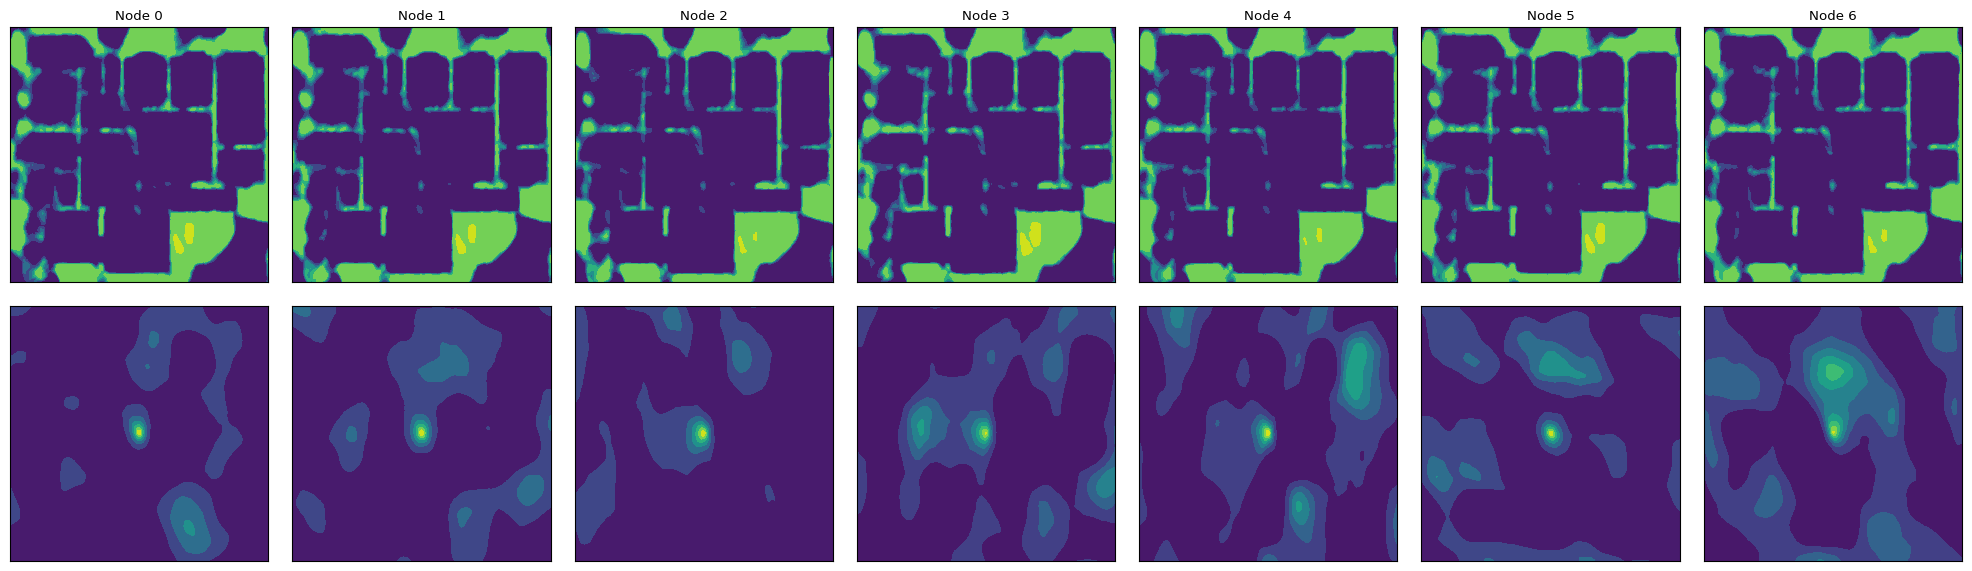

In [105]:
dens1 = results1["mesh_grid_density"]
# dens2 = results2["mesh_grid_density"]
locs = results3["mesh_inputs"]

N = 7
(fig, axs) = plt.subplots(nrows=2, ncols=N, figsize=(20, 6), tight_layout=True)

for i in range(N):
    pred1 = (torch.squeeze(dens1[-1]))[i, :]
    axs[0, i].tricontourf(locs[:, 0], locs[:, 1], pred1)
    axs[0, i].set_title("Node {}".format(i))
    axs[0, i].set_xticklabels([])
    axs[0, i].set_xticks([])
    axs[0, i].set_yticklabels([])
    axs[0, i].set_yticks([])
    pred2 = (torch.squeeze(results_solo[i]["mesh_grid_density"]))
    axs[1, i].tricontourf(locs[:, 0], locs[:, 1], pred2)
    axs[1, i].set_xticklabels([])
    axs[1, i].set_xticks([])
    axs[1, i].set_yticklabels([])
    axs[1, i].set_yticks([])

fig.savefig("odense_mesh.svg")

In [ ]:
dens1 = results3["mesh_grid_density"]
# dens2 = results2["mesh_grid_density"]
locs = results1["mesh_inputs"]

N = 7
(fig, axs) = plt.subplots(nrows=2, ncols=4, figsize=(20, 8), tight_layout=True)
axs[1, 3].remove()
colors = list(cm.get_cmap("Dark2").colors)
colors[0] = "orangered"

i = 0
for ax in axs.flatten():
    if i == 7:
        break
    # Waypoint Settings
    wp_names = glob.glob1(os.path.join(data_dir, waypoint_subdir), "*.npy") 
    
    wp_path = os.path.join(data_dir, waypoint_subdir, wp_names[i])
    wps = np.load(wp_path)
    dataset = OnlineTrajectoryLidarDataset(lidar, wps, 
        spline_res, num_scans_in_window)

    pred2 = (torch.squeeze(results_solo[i]["mesh_grid_density"]))
    pred1 = (torch.squeeze(dens1[-1]))[i, :]
    
    ax.tricontourf(locs[:, 0], locs[:, 1], pred1)
    ax.plot(dataset.scan_locs[:, 0], dataset.scan_locs[:, 1], linewidth=2, color=colors[i])
    ax.set_xticklabels([])
    ax.set_xticks([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    i += 1

fig.savefig("odense_mesh_inds.svg")

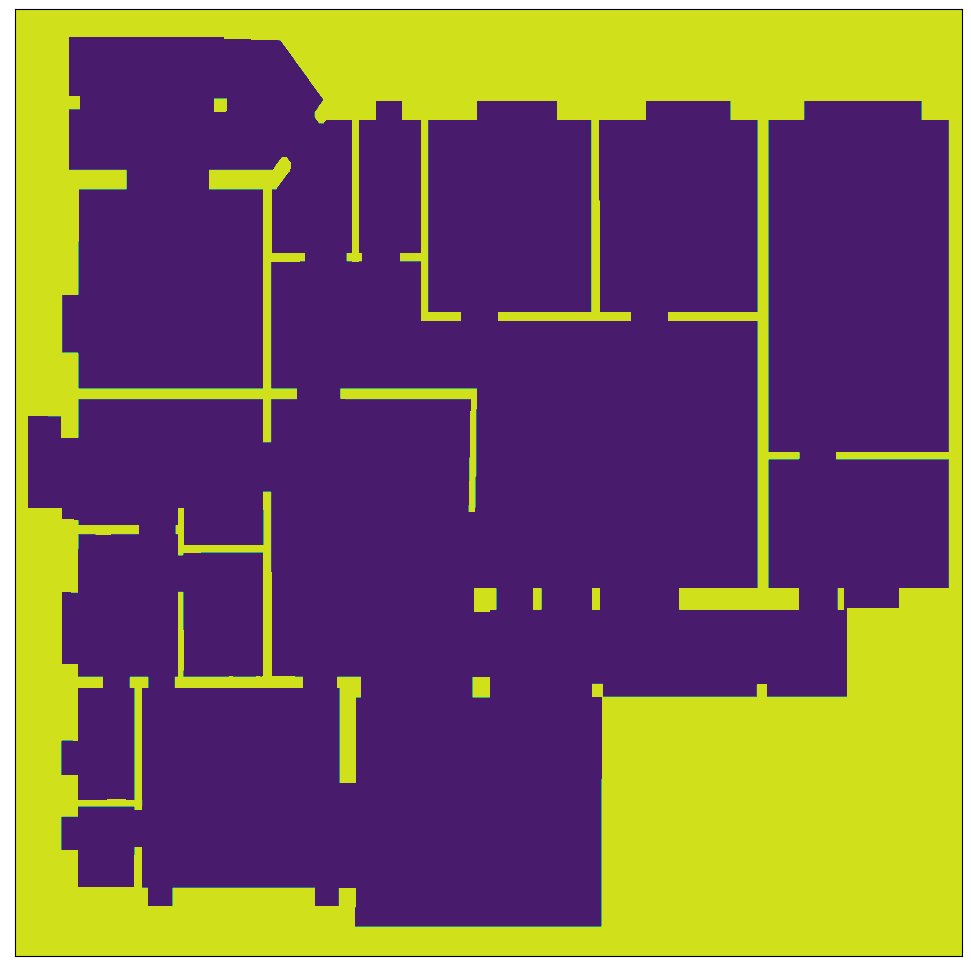

In [17]:
fig, ax = plt.subplots(tight_layout=True, figsize=(10, 10))
X, Y = np.meshgrid(lidar.xs, lidar.ys)
ax.contourf(X, Y, lidar.img)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticklabels([])
ax.set_yticks([])

fig.savefig("odense_ground_truth.svg")

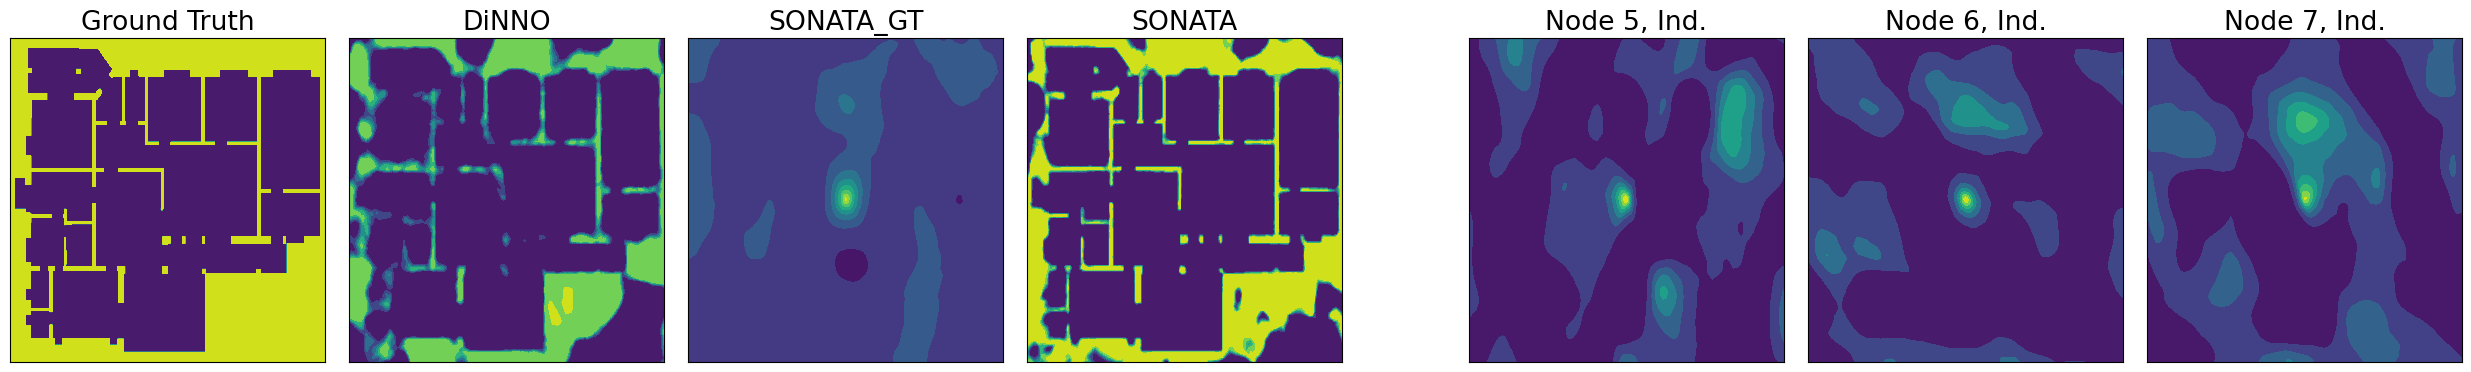

In [6]:
dens1 = results1["mesh_grid_density"]
dens2 = results2["mesh_grid_density"]
dens3 = results3["mesh_grid_density"]
locs = results1["mesh_inputs"]

(fig, axs) = plt.subplots(nrows=1, ncols=8, figsize=(25, 4), tight_layout=True, 
    gridspec_kw=dict(width_ratios=[4,4,4,4,1,4,4,4], hspace=0))
X, Y = np.meshgrid(lidar.xs, lidar.ys)
axs[0].contourf(X, Y, lidar.img)
axs[0].set_title("Ground Truth")
axs[0].set_xticklabels([])
axs[0].set_xticks([])
axs[0].set_yticklabels([])
axs[0].set_yticks([])

axs[1].tricontourf(locs[:, 0], locs[:, 1], (torch.squeeze(dens1[-1]))[0, :])
axs[1].set_title("DiNNO")
axs[1].set_xticklabels([])
axs[1].set_xticks([])
axs[1].set_yticklabels([])
axs[1].set_yticks([])

axs[2].tricontourf(locs[:, 0], locs[:, 1], (torch.squeeze(dens2[-1]))[0, :])
axs[2].set_title("SONATA_GT")
axs[2].set_xticklabels([])
axs[2].set_xticks([])
axs[2].set_yticklabels([])
axs[2].set_yticks([])

axs[3].tricontourf(locs[:, 0], locs[:, 1], (torch.squeeze(dens3[-1]))[0, :])
axs[3].set_title("SONATA")
axs[3].set_xticklabels([])
axs[3].set_xticks([])
axs[3].set_yticklabels([])
axs[3].set_yticks([])

axs[4].remove()

for i in range(5, 8):    
    pred2 = (torch.squeeze(results_solo[i-1]["mesh_grid_density"]))
    axs[i].tricontourf(locs[:, 0], locs[:, 1], pred2)
    axs[i].set_xticklabels([])
    axs[i].set_xticks([])
    axs[i].set_yticklabels([])
    axs[i].set_yticks([])
    axs[i].set_title("Node {}, Ind.".format(i))

fig.savefig("odense_allalg_mesh.png", dpi=800)

In [ ]:
ag_cadmm = torch.vstack([v[1].reshape(1, -1) for v in results1["consensus_error"]])
ag_dsgt = torch.vstack([v[1].reshape(1, -1) for v in results2["consensus_error"]])
ag_dsgd = torch.vstack([v[1].reshape(1, -1) for v in results3["consensus_error"]])
ori_dsgt = torch.vstack([v[1].reshape(1, -1) for v in results4["consensus_error"]])

(fig, ax) = plt.subplots(figsize=(10, 8), tight_layout=True)
ax.plot(ag_cadmm[1:, :6],  zorder=3)
ax.plot(ag_cadmm[1:, 6],  label="DiNNO", zorder=3)

ax.plot(ag_dsgt[1:, :6], c=dsgt_color, zorder=2)
ax.plot(ag_dsgt[1:, 6], c=dsgt_color, label="SONATA_GT", zorder=2)

ax.plot(ag_dsgd[1:, :6], c=dsgd_color, zorder=1)
ax.plot(ag_dsgd[1:, 6], c=dsgd_color, label="SONATA", zorder=1)
ax.plot(ori_dsgt[1:, :6], c=ori_color, zorder=1)
ax.plot(ori_dsgt[1:, 6], c=ori_color, label="GT", zorder=1)

ax.set_yscale("log")
ax.grid()
ax.set_xlabel("Communication Round")
ax.set_ylabel("Disagreement")
ax.legend(loc=1)
fig.savefig("odense_agree.svg")

In [ ]:
print(ag_dsgd[0])

In [7]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
import math

def MSE(X_test, X_hat, start_time = 0):

    mse_per_frame = np.mean(((X_test[:, start_time:] - X_hat[:, start_time:])**2), axis=(2,3))
    mse_score = np.mean( (X_test[:, start_time:] - X_hat[:, start_time:])**2 )

    return mse_score, mse_per_frame


def SSIM(X_test, X_hat, start_time = 0):

    num_images, num_timesteps, _, _ = X_test.shape
    ssim_values = []

    for idx in range(num_images):
        for t in range(start_time, num_timesteps):
            img_truth =  X_test[idx,t,:,:]
            img_hat = X_hat[idx,t,:,:]
            ssim_img = ssim(img_truth, img_hat, data_range=img_truth.max() - img_truth.min())
            if math.isnan(ssim_img):
                continue
            ssim_values.append(ssim_img)

    ssim_model = np.mean(ssim_values)

    return ssim_model, ssim_values

In [ ]:
from models.fourier_nn import FourierNet
cent_dir="../centralized/"
cen_result=torch.load(os.path.join(cent_dir, "minimal_overlap.pt"),map_location=torch.device('cuda'))
model = FourierNet([2, 256, 64, 64, 64, 1], scale=0.05).to("cuda")
model.load_state_dict(cen_result)
X, Y = np.meshgrid(torch.Tensor(lidar.xs), torch.Tensor(lidar.ys))
xlocs = X[::8, ::8].reshape(-1, 1)
ylocs = Y[::8, ::8].reshape(-1, 1)
xlocs=torch.Tensor(xlocs)
ylocs=torch.Tensor(ylocs)
mesh_inputs = torch.hstack((xlocs, ylocs))
mesh_inputs = mesh_inputs.to("cuda")

with torch.no_grad():
    mesh_dense = model.forward(mesh_inputs)
torch.save(mesh_dense, "mesh_dense.pt")
    

In [ ]:
# locs = results1["mesh_inputs"]
# height=201
# width=271
# for i in range(locs.shape[0]):
#         x_i = i % width
#         y_i = i // width
#         # 计算对应的 gt 索引
#         gt_x = min(x_i * 8, lidar.img.shape[0] - 1)
#         gt_y = min(y_i * 8, lidar.img.shape[1] - 1)
#         a
X, Y = np.meshgrid(lidar.xs, lidar.ys)
xlocs = X[::8, ::8].reshape(-1, 1)
ylocs = Y[::8, ::8].reshape(-1, 1)
mesh_poses = np.hstack((xlocs, ylocs))
plt.tricontourf(mesh_poses[:,0],mesh_poses[:,1],lidar.img[::8, ::8].reshape(-1))
# plt.tricontourf(mesh_poses[:,0],mesh_poses[:,1],den.squeeze())

In [8]:
from skimage.metrics import structural_similarity as ssim
def MSE(pred, gt):
    
    error=np.mean((pred-gt)**2)
    return error
def SSIM(pred, gt):
    
    return ssim(gt, pred, data_range=gt.max() - gt.min())
def PSNR(pred, gt):
    mse = MSE(pred, gt)
    return 10 * np.log10(1 / mse)
def BCCC(pred, gt):
    pred = pred.flatten()
    gt = gt.flatten()
    pred_mean = np.mean(pred)
    gt_mean = np.mean(gt)
    pred_std = np.std(pred)
    gt_std = np.std(gt)
    n = len(pred)
    bccc = np.sum((pred-pred_mean)*(gt-gt_mean))/(n*pred_std*gt_std)
    return bccc
def print_value(pred,gt,name):
    if isinstance(pred1, torch.Tensor):
            pred = pred.numpy()
    print(name,"MSE: ", MSE(pred, gt),"SSIM: ", SSIM(pred, gt),"PSNR: ", PSNR(pred, gt),"BCCC: ", BCCC(pred, gt))
    return

In [ ]:
print(pred3[:10],mesh_dense[:10]
)

dinno MSE:  0.12496056922559881 SSIM:  0.6570424396841978 PSNR:  9.032270051459246 FP:  0.001745962461807071 FN:  0.30070165590794273 BCCC:  0.7118387388632019
sonata MSE:  0.08354287332826396 SSIM:  0.8093742539451689 PSNR:  10.780905919252167 FP:  0.005101484068092536 FN:  0.2214426045467303 BCCC:  0.8080248393404053
centralized MSE:  0.012816120190645545 SSIM:  0.9356493460977103 PSNR:  18.922434283908164 FP:  0.0032191182889567873 FN:  0.019477968004490597 BCCC:  0.9705252089243328


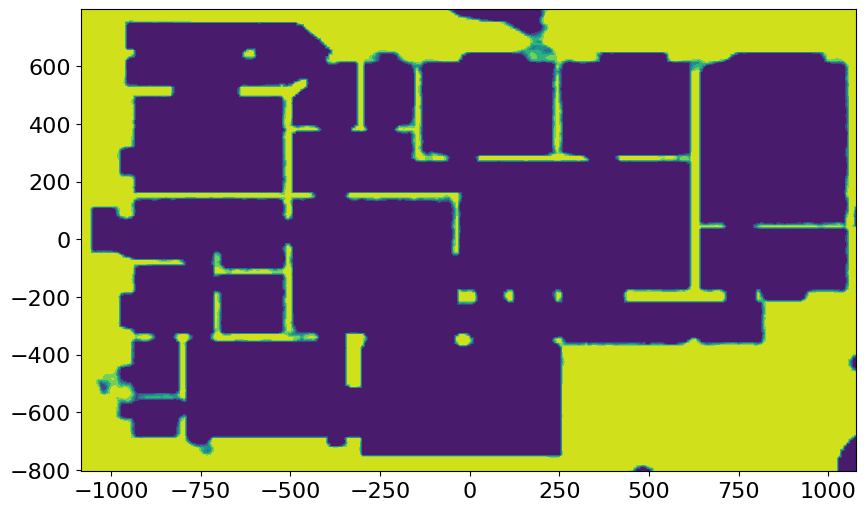

In [34]:
fig, ax = plt.subplots( figsize=(10, 6))
# X, Y = torch.meshgrid(torch.Tensor(lidar.xs), torch.Tensor(lidar.ys))

X, Y = np.meshgrid(lidar.xs, lidar.ys)
xlocs = X[::8, ::8].reshape(-1, 1)
ylocs = Y[::8, ::8].reshape(-1, 1)
gt=lidar.img[::8, ::8].reshape(-1)
# ax.contourf(X, Y, lidar.img)
# ax.set_xticklabels([])
# ax.set_xticks([])
# ax.set_yticklabels([])
# ax.set_yticks([])
dens3= results3["mesh_grid_density"]
dens1 = results1["mesh_grid_density"]
cen_den=torch.load("mesh_dense.pt",map_location=torch.device('cpu'))
# den=mesh_dense.cpu()
locs = results1["mesh_inputs"]
pred= (torch.squeeze(den))
pred1= (torch.squeeze(dens1[-1]))[0, :]
# ax.tricontourf(locs[:, 0], locs[:, 1], den.squeeze())
ax.tricontourf(xlocs.squeeze(), ylocs.squeeze(), den.squeeze())

pred3= (torch.squeeze(dens3[-1]))[0, :]
from utils.metric import print_value
print_value(pred1,gt,"dinno")
print_value(pred3,gt,"sonata")
print_value(pred,gt,"centralized")
# print("dsgt:")



(array([39020.,   559.,   412.,   353.,   335.,   352.,   422.,   522.,
          970., 11526.]),
 array([2.73886508e-145, 9.99996271e-002, 1.99999254e-001, 2.99998881e-001,
        3.99998509e-001, 4.99998136e-001, 5.99997763e-001, 6.99997390e-001,
        7.99997017e-001, 8.99996644e-001, 9.99996271e-001]),
 <BarContainer object of 10 artists>)

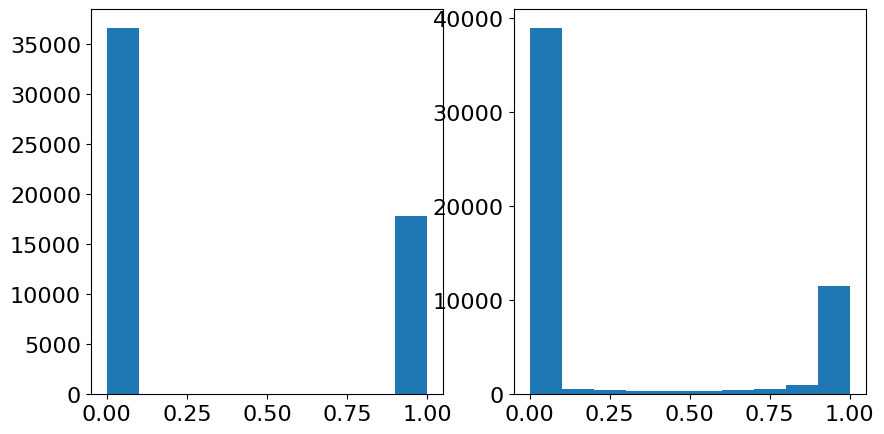

In [18]:
fig,axs=plt.subplots(1,2,figsize=(10,5))
axs[0].hist(gt)
axs[1].hist(pred3)